<a href="https://colab.research.google.com/github/Ropafadzo-Choto1/FUTURE_DS_01/blob/main/Superstore.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Task1
import pandas as pd

pd.options.display.float_format = '{:.2f}'.format
df = pd.read_csv("/content/Sample - Superstore.csv", encoding='latin1', usecols=lambda column: column != "Row ID")


df.head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91
1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58
2,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87
3,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03
4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52


In [ ]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

# Check data
df.head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91
1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58
2,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87
3,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03
4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52


<Axes: title={'center': 'Monthly Revenue Trend'}, xlabel='Month'>

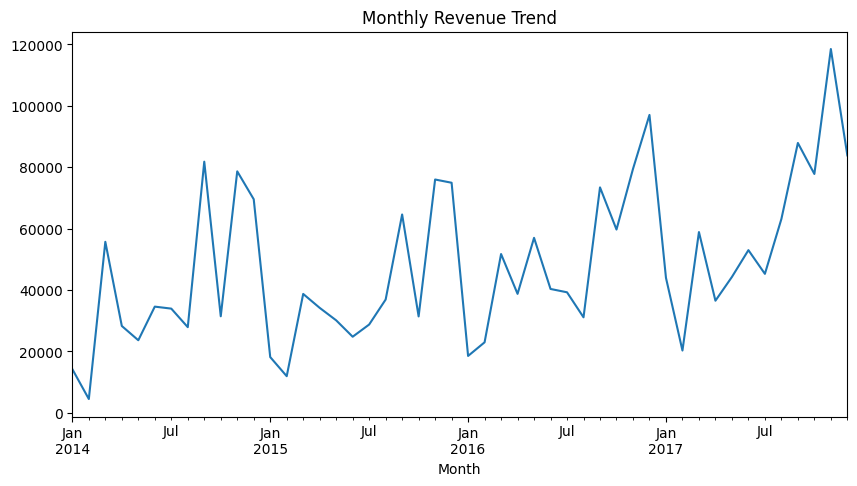

In [ ]:
df["Month"] = df["Order Date"].dt.to_period("M")

monthly_sales = df.groupby("Month")["Sales"].sum()

monthly_sales.plot(figsize=(10,5), title="Monthly Revenue Trend")

## 📊 Revenue Trend Analysis

### Objective
This analysis will examine historical sales data and identify revenue trends over time in order to understand business performance and possible seasonal patterns.

### Monthly Revenue Trend
The line chart above illustrates the **monthly revenue from 2014 to 2017**. By analyzing the trend, several important insights about the company's sales performance can be identified.

### Key Findings

**1. Overall Growth Trend**  
The revenue shows a **general upward trend over the four-year period**. While monthly values fluctuate, the later years particularly **2017—record higher revenue levels**, indicating overall business growth.

**2. Seasonal Sales Patterns**  
There appears to be a **repeating seasonal pattern** where revenue tends to increase toward the **end of each year**. This may be driven by holiday shopping, promotional campaigns, or increased customer demand during specific periods.

**3. Low Revenue Periods**  
Revenue drops are noticeable at the **beginning of some years**, especially around **early 2015, 2016, and 2017**. These decreases could reflect slower post-holiday demand or typical seasonal slowdowns.

**4. Revenue Peaks**  
Several **significant spikes in revenue** are visible across the timeline. The **highest peak occurs in late 2017**, reaching approximately **$120,000**, suggesting a period of particularly strong sales performance.


### Conclusion
This analysis shows that while monthly revenue fluctuates, the overall trend shows **steady growth combined with recurring seasonal peaks**. These insights provide valuable information for strategic business planning and decision-making.

In [ ]:
top_products = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False)

top_products.head(10)

,Sales
Product Name,
Canon imageCLASS 2200 Advanced Copier,61599.82
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.38
Cisco TelePresence System EX90 Videoconferencing Unit,22638.48
HON 5400 Series Task Chairs for Big and Tall,21870.58
GBC DocuBind TL300 Electric Binding System,19823.48
GBC Ibimaster 500 Manual ProClick Binding System,19024.50
Hewlett Packard LaserJet 3310 Copier,18839.69
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.90
GBC DocuBind P400 Electric Binding System,17965.07


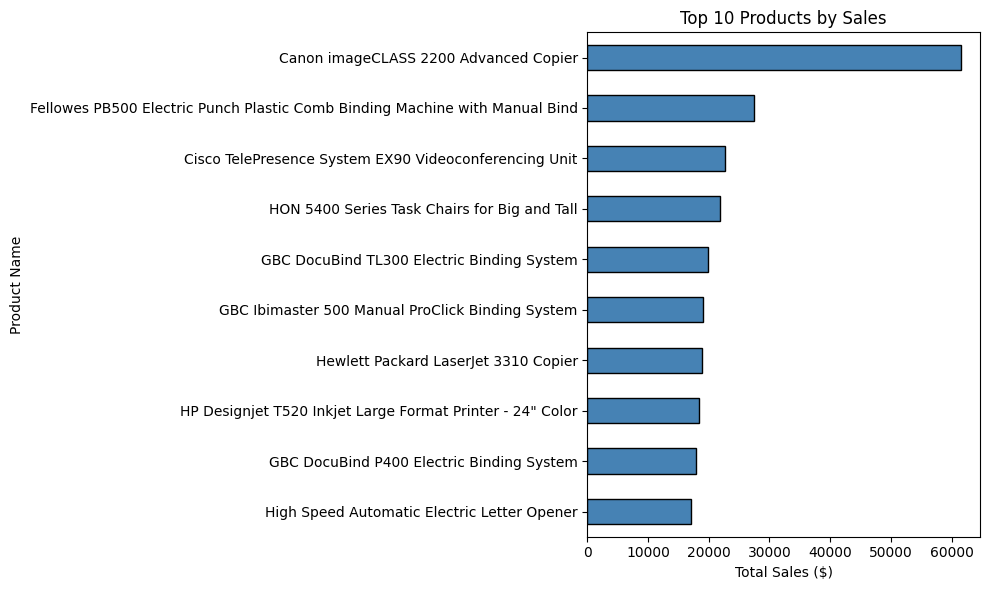

In [ ]:
import matplotlib.pyplot as plt

top_products = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False)
top10 = top_products.head(10)

plt.figure(figsize=(10,6))
top10.sort_values().plot(kind="barh", color="steelblue", edgecolor="black")

plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales ($)")
plt.ylabel("Product Name")

plt.tight_layout()
plt.show()

In [ ]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

category_sales

,Sales
Category,
Technology,836154.03
Furniture,741999.80
Office Supplies,719047.03


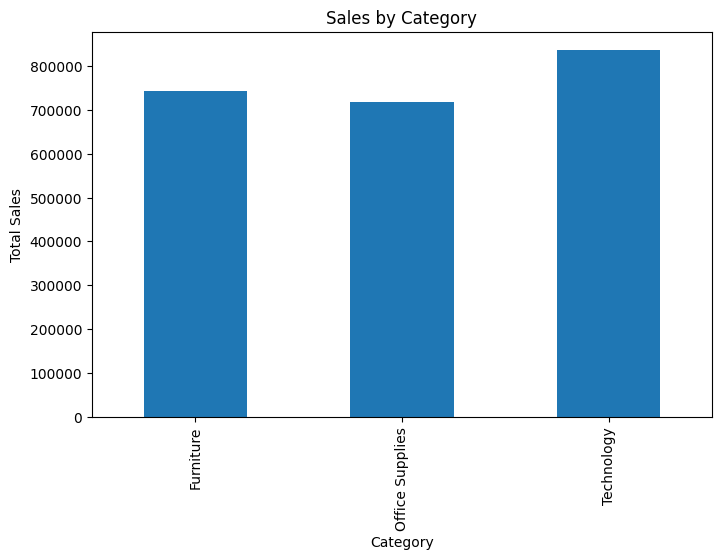

In [ ]:
import matplotlib.pyplot as plt

# Assuming 'df' DataFrame is already loaded and preprocessed by earlier cells
# df = pd.read_csv("/content/Sample - Superstore.csv", encoding='latin1') # Removed redundant loading
# df["Order Date"] = pd.to_datetime(df["Order Date"]) # Removed redundant preprocessing

category_sales = df.groupby("Category")["Sales"].sum()

plt.figure(figsize=(8,5))
category_sales.plot(kind="bar")
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()

In [ ]:
subcategory_sales = df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False)

subcategory_sales.head(10)

,Sales
Sub-Category,
Phones,330007.05
Chairs,328449.10
Storage,223843.61
Tables,206965.53
Binders,203412.73
Machines,189238.63
Accessories,167380.32
Copiers,149528.03
Bookcases,114880.00


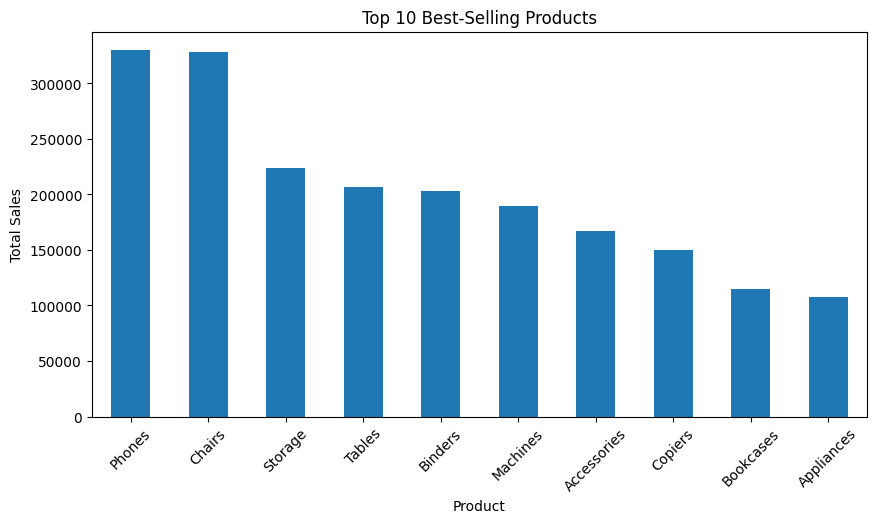

In [ ]:
top_products = df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_products.plot(kind="bar")
plt.title("Top 10 Best-Selling Products")
plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

Business Sales Data Analysis

### Objective
Understanding which products sells helps businesses improve decision-making, optimize marketing strategies, and increase profitability.

---

## 1. Top-Selling Products

The products generating the highest sales revenue include:

- Canon imageCLASS 2200 Advanced Copier – $61,599.82

- Fellowes PB500 Electric Punch Plastic Comb Binding Machine – $27,453.38

- Cisco TelePresence System EX90 Videoconferencing Unit – $22,638.48

- HON 5400 Series Task Chairs for Big and Tall – $21,870.58  

- GBC DocuBind TL300 Electric Binding System – $19,823.48  

### Insight
High-value office equipment and technology products generate the **largest individual product sales**, indicating strong demand for professional office solutions.

---

### Sales by Category

Total revenue by category:

Technology - $836,154.03

Furniture - $741,999.80  

Office Supplies - $719,047.03

### Insight
The **Technology category generates the highest revenue**, making it the most valuable product category for the business. Furniture and Office Supplies also contribute significantly to total sales.

---

## 3. Sales by Sub-Category

Top-performing sub-categories include:

- Phones – $330,007.05  

- Chairs – $328,449.10

- Storage – $223,843.61

- Tables – $206,965.53

- Binders – $203,412.73  

### Insight
Communication and office infrastructure products such as **Phones and Chairs** generate the highest sales, suggesting that businesses prioritize workplace equipment and communication tools.

---

In [ ]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

region_sales

,Sales
Region,
West,725457.82
East,678781.24
Central,501239.89
South,391721.91


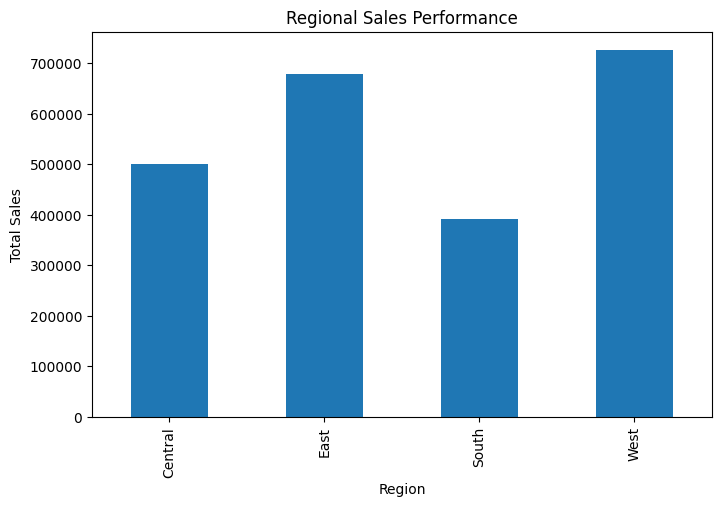

In [ ]:
region_sales = df.groupby("Region")["Sales"].sum()

plt.figure(figsize=(8,5))
region_sales.plot(kind="bar")
plt.title("Regional Sales Performance")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.show()

In [ ]:
region_profit = df.groupby("Region")["Profit"].sum().sort_values(ascending=False)

region_profit

,Profit
Region,
West,108418.45
East,91522.78
South,46749.43
Central,39706.36


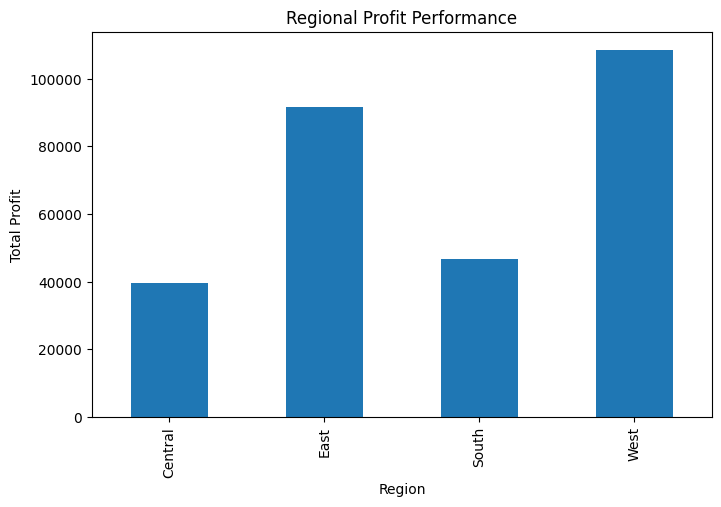

In [ ]:
region_profit = df.groupby("Region")["Profit"].sum()

plt.figure(figsize=(8,5))
region_sales.plot(kind="bar")
plt.title("Regional Profit Performance")
plt.xlabel("Region")
plt.ylabel("Total Profit")
plt.show()

### Regional Sales and Profit Performance

The West region leads both **sales($725,457.82)** and            **profit(108,418.45)**, indicating a strong and profitable market. The East region also performs well, while the Central and South regions lag behind.


**Insight:**  
The company could focus on **expanding operations or marketing efforts in the West and East regions**, while investigating why the South and Central regions generate lower returns.

---





In [ ]:
df.groupby("Discount")["Profit"].mean()

,Profit
Discount,
0.00,66.90
0.10,96.06
0.15,27.29
0.20,24.70
0.30,-45.68
0.32,-88.56
0.40,-111.93
0.45,-226.65
0.50,-310.70


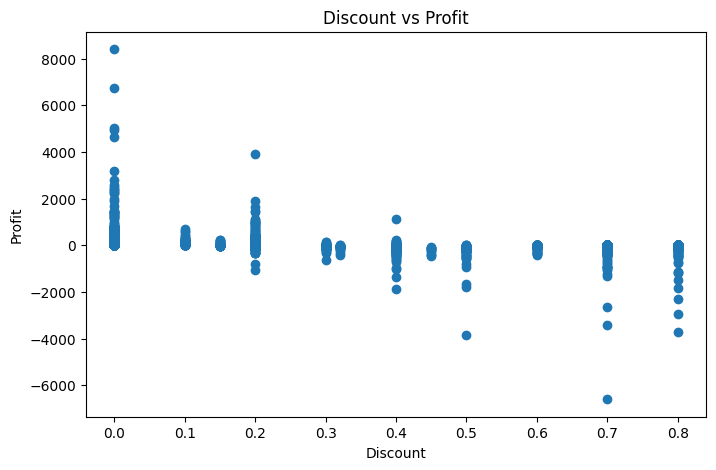

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df["Discount"], df["Profit"])
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()

In [ ]:
df[["Sales","Discount","Profit"]].corr()

,Sales,Discount,Profit
Sales,1.00,-0.03,0.48
Discount,-0.03,1.00,-0.22
Profit,0.48,-0.22,1.00


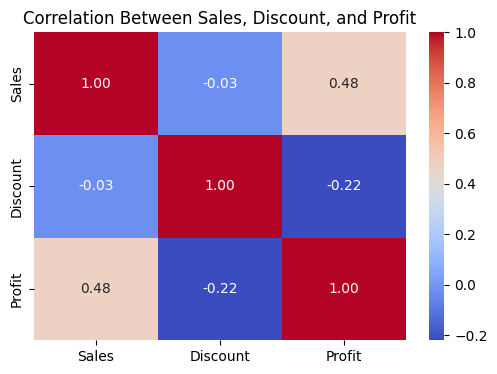

In [ ]:
import seaborn as sns
corr = df[["Sales","Discount","Profit"]].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Between Sales, Discount, and Profit")
plt.show()

### High Discounts Reduce Profitability
Profit analysis shows that profits become negative when discounts exceed approximately **30%**. For example:

- 45% Discount → Profit: -226.65  
- 50% Discount → Profit: -310.70  

**Insight:**  
Excessive discounting significantly harms profitability. The company should consider **limiting discount rates or implementing smarter promotional strategies**.

---

## 📊 My Business Recommendations

### **1. Focus on High-Revenue Product Categories**

The Technology category generates the highest revenue, followed by Furniture and Office Supplies. The company should prioritize investment and marketing in these areas, especially for high-demand products such as phones, chairs, and office equipment. Expanding the product range and ensuring adequate inventory for these items can help increase sales and support continued revenue growth.

### **2. Strengthen Sales in High-Performing Regions**

The West region generates the highest sales and profit, while the East region also performs strongly. The company should increase marketing efforts, sales activities, and distribution channels in these regions to maximize revenue opportunities. Expanding operations in these strong markets could further increase overall profitability.

### **3. Improve Performance in Underperforming Regions**

The Central and South regions show lower sales and profitability compared to other regions. The company should investigate possible reasons for this performance, such as lower demand, pricing strategies, or limited marketing efforts. Targeted promotions, localized marketing campaigns, and adjustments in product offerings could help improve sales in these regions.

### **4. Optimize Discount Strategies**

The analysis shows that discounts above approximately 30% often lead to negative profit. To protect profitability, the company should limit excessive discounting and instead implement smarter promotional strategies such as targeted discounts, bundle offers, or loyalty programs. This approach can maintain customer interest while preserving profit margins.

### **5. Prepare for Seasonal Demand Patterns**

Revenue trends indicate that sales increase toward the end of each year, while the beginning of the year typically shows lower revenue. The company should prepare for these seasonal patterns by increasing inventory, marketing activities, and promotional campaigns before peak demand periods. During slower months, special promotions or new product launches could help stimulate demand.

### **6. Use Sales Forecasting for Strategic Planning**

The overall upward trend in revenue suggests steady business growth. The company should use historical sales data and forecasting techniques to predict future demand, plan inventory levels, allocate resources effectively, and support long-term strategic decision-making.

### **Conclusion**

Overall, the analysis indicates steady business growth driven by strong demand for technology and office infrastructure products. By focusing on high-performing products, strengthening profitable regions, managing discount levels carefully, and preparing for seasonal demand patterns, the company can improve profitability and sustain long-term growth.
